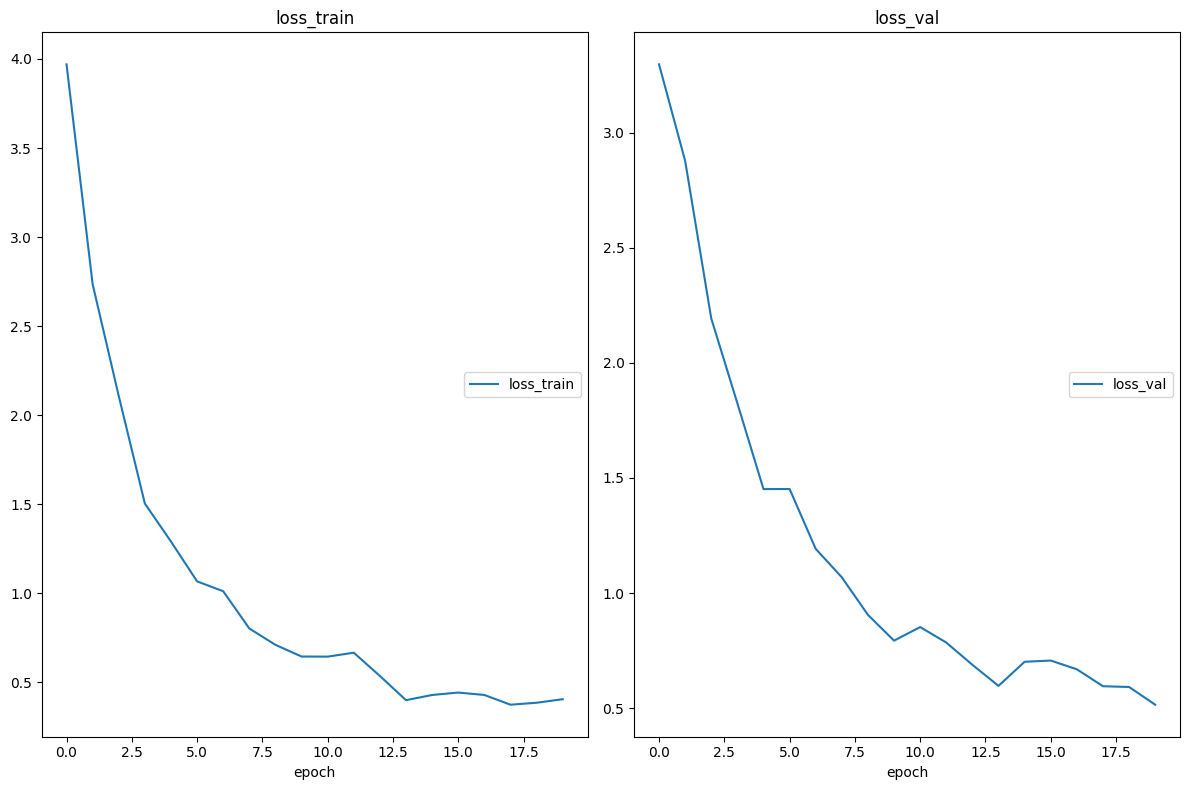

epoch: 100%|██████████| 20/20 [2:05:22<00:00, 376.14s/it]

loss_train
	loss_train       	 (min:    0.373, max:    3.970, cur:    0.404)
loss_val
	loss_val         	 (min:    0.515, max:    3.297, cur:    0.515)


In [2]:
"""
Imports

"""

import random
import uproot
import awkward as ak
import argparse
import logging
from tqdm import tqdm
from pathlib import Path
import os
import sys
import json
import h5py


import numpy as np
import torch
from torch.utils.data import IterableDataset, Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import EdgeConv, global_mean_pool
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.cuda.amp import GradScaler, autocast
from livelossplot import PlotLosses
from torch_geometric.loader import DataLoader
import torch_cluster



sys.path.append('/global/cfs/cdirs/m4474/aneek/particlemind_aneek')

from src.data.augmentation import *
from src.data.dataset import ColliderMLHits, ContrastiveLearningDataset, ContrastiveLearningGraphDataset, EventGraphBuilder
from src.models.gnn import *
from src.models.contrastive_learning import *
from src.data.coarsening import voxelize_hits


from torch.utils.tensorboard import SummaryWriter
import argparse
import torch.backends.cudnn as cudnn
from torchvision import models



model_names = sorted(name for name in models.__dict__
                     if name.islower() and not name.startswith("__")
                     and callable(models.__dict__[name]))

parser = argparse.ArgumentParser(description='ColliderML Training')


#parser.add_argument('-data', metavar='DIR', default='./datasets',help='path to dataset')

parser.add_argument('-dataset-name', default='colliderml',
                    help='dataset name')

parser.add_argument('-a', '--arch', metavar='ARCH', default='gnn',
                    help='model architecture: ')




parser.add_argument('--trainevents', default=640, type=int,
                    help='number of events used for training ')

parser.add_argument('--split', default='dihiggs_scale_5.0_events_1500', help='dataset type')

parser.add_argument('--rotation', default=np.pi/8, help='scale for random global rotation')

parser.add_argument('--energy-noise', default=0.05, help='scale for (log)-energy noise')

parser.add_argument('--off', default=0, type=int, help='loading weights from previously trained model')





parser.add_argument('-j', '--workers', default=12, type=int, metavar='N',
                    help='number of data loading workers (default: 32)')

parser.add_argument('--epochs', default=20, type=int, metavar='N',
                    help='number of total epochs to run')


parser.add_argument('-b', '--batch-size', default=64, type=int,
                    metavar='N',
                    help='mini-batch size, this is the total '
                         'batch size of all GPUs on the current node when '
                         'using Data Parallel or Distributed Data Parallel')


parser.add_argument('--lr', '--learning-rate', default=0.001, type=float,
                    metavar='LR', help='initial learning rate', dest='lr')

parser.add_argument('--wd', '--weight-decay', default=1e-4, type=float,
                    metavar='W', help='weight decay (default: 1e-4)',
                    dest='weight_decay')

parser.add_argument('--seed', default=42, type=int,
                    help='seed for initializing training. ')

parser.add_argument('--disable-cuda', action='store_true',
                    help='Disable CUDA')

parser.add_argument('--fp16-precision', action='store_true',
                    help='Whether or not to use 16-bit precision GPU training.')

parser.add_argument('--out_dim', default=32, type=int,
                    help='latent space dimension where constrastive loss is applied')

parser.add_argument('--feat_dim', default=4, type=int,
                    help='feature dimension')

parser.add_argument('--log-every-n-steps', default=100, type=int,
                    help='Log every n steps')

parser.add_argument('--temperature', default=0.07, type=float,
                    help='softmax temperature (default: 0.07)')

parser.add_argument('--n-views', default=2, type=int, metavar='N',
                    help='Number of views for contrastive learning training.')

parser.add_argument('--gpu-index', default=0, type=int, help='Gpu index.')


args, unknown = parser.parse_known_args()

## save the args---done Later

assert args.n_views == 2, "Only two view training is supported. Please use --n-views 2."
    # check if gpu training is available
if not args.disable_cuda and torch.cuda.is_available():
    args.device = torch.device('cuda')
    torch.backends.cudnn.deterministic = True
    cudnn.benchmark = True    
else:
    args.device = torch.device('cpu')
    args.gpu_index = -1


    
# Fixing seed after parsing args
if args.seed is not None:
    SEED = args.seed

else:

    SEED = 42  # or any fixed integer


random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)




"""
Loading ColliderML data

"""

from colliderml.core import load_tables, collect_tables


## ttbar data
cfg1 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "ttbar",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": args.trainevents,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables1 = load_tables(cfg1)
frames1 = collect_tables(tables1)

calo_hits1 = frames1["calo_hits"]


## dihiggs data
cfg2 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "dihiggs",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": args.trainevents,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables2 = load_tables(cfg2)
frames2 = collect_tables(tables2)

calo_hits2 = frames2["calo_hits"]

## ggf data
cfg3 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "ggf",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": args.trainevents,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables3 = load_tables(cfg3)
frames3 = collect_tables(tables3)

calo_hits3 = frames3["calo_hits"]

import polars as pl

# Concatenate
#combined = pl.concat([calo_hits1, calo_hits2, calo_hits3])
combined = pl.concat([calo_hits1, calo_hits2])
#combined = pl.concat([calo_hits2, calo_hits3])

#combined = calo_hits2 #Only dihiggs

# Shuffle rows
combined = combined.sample(fraction=1.0, with_replacement=False, seed=SEED)

#print(combined.shape)
#print(combined.head())

calo_hits = combined



"""

Preparing dataset

"""


augment = Compose([
    RandomRotateXY(angle_range=(-args.rotation, args.rotation), gaussian = False),
    EnergyWhiteNoise(args.energy_noise),
    NoiseXYZ(5.0)
])




dataset_train = ColliderMLHits(calo_hits, split="train", shuffle_files=False, train_fraction=0.8, log=False)
dataset_val = ColliderMLHits(calo_hits, split="val", shuffle_files=False, train_fraction=0.8, log=False)

r = 0 # r does not matter for GravNetEncoder, but for GraphConvEncoder



MEANS = None
STDS = None





contrastive_dataset_train = ContrastiveLearningDataset(dataset_train, MEANS, STDS,  augment, voxel_size=100.0)

MEANS, STDS = contrastive_dataset_train.compute_mean_std(max_samples=50)

contrastive_dataset_val = ContrastiveLearningDataset(dataset_val, MEANS, STDS,  augment, voxel_size=100.0)


dataset_train = ContrastiveLearningGraphDataset(contrastive_dataset_train, builder=EventGraphBuilder(radius=r))

dataset_val = ContrastiveLearningGraphDataset(contrastive_dataset_val, builder=EventGraphBuilder(radius=r))



train_loader = DataLoader(dataset_train, batch_size=args.batch_size, drop_last=True)
val_loader   = DataLoader(dataset_val,   batch_size=args.batch_size, drop_last=True)



print("Data preprocessing working fine.")










"""
TRAIN THE MODEL

"""




"""
Specify the model
"""

#model = PointNetEncoder()

model = GravNetEncoder(in_features=4, hidden_dim=16, latent_dim=64, proj_dim=32, k=8, space_dim=4, propagate_dim=16) # adjust the in_features properly, 2+1=3 for planar projections of hits




def count_trainable_parameters(mymodel):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Trainable parameters:", count_trainable_parameters(model))




"""
Specify the folder
"""

'''
folder = '/global/cfs/cdirs/m4474/aneek/particlemind_aneek/saved_models_colliderml_latest/gravnet_models_{}_rot_{:.2f}_noise_{:.2f}/'.format(args.split, args.rotation, args.energy_noise)
    
os.makedirs(folder, exist_ok=True)
    
np.save(folder+'stats.npy',{'means': MEANS, 'stds': STDS, 'events': 544})



# Save the args
def serializable_args(args):
    return {k: str(v) if not isinstance(v, (int, float, str, bool, type(None))) else v
            for k, v in vars(args).items()}



json.dump(serializable_args(args), open(folder+'args.json', "w"), indent=4)
'''

# Load previous weights if needed

if args.off>0 :

    prev_weights = torch.load(folder+f'model_epoch_{args.off}.pth', map_location='cpu')   # add this)

    model.load_state_dict(prev_weights)




# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print(device)




optimizer = torch.optim.Adam(model.parameters(), args.lr, weight_decay=args.weight_decay)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=len(train_loader), eta_min=0, last_epoch=-1)

#  It’s a no-op if the 'gpu_index' argument is a negative integer or None.



"""
Train the model
"""

with torch.cuda.device(args.gpu_index):
    
    simclr = Contrastive_Learning(model=model, optimizer=optimizer, scheduler=scheduler, args=args)


      
    simclr.train(train_loader, val_loader, off=args.off, skip=1, save_model=False, folder = None, wandb_=False, key='', name='gravnet_models_{}_rot_{:.2f}_noise_{:.2f}'.format(args.split, args.rotation, args.energy_noise))

   

## Evaluation

100%|██████████| 19/19 [05:44<00:00, 18.13s/it]


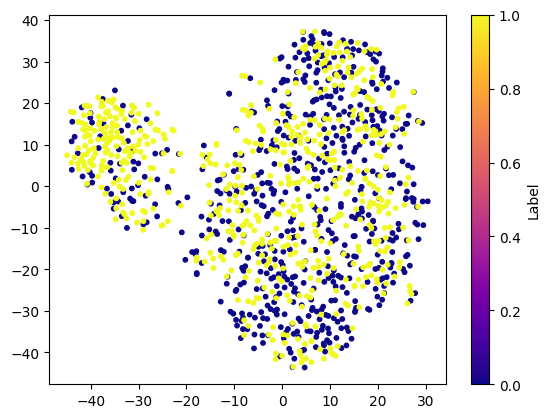

In [18]:
"""
Imports

"""

import random
import uproot
import awkward as ak
import argparse
import logging
from tqdm import tqdm
from pathlib import Path
import os
import sys
import json
import h5py


import numpy as np
import torch
from torch.utils.data import IterableDataset, Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import EdgeConv, global_mean_pool
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from torch.cuda.amp import GradScaler, autocast
from livelossplot import PlotLosses
from torch_geometric.loader import DataLoader
import torch_cluster



sys.path.append('/global/cfs/cdirs/m4474/aneek/particlemind_aneek')

from src.data.augmentation import *
from src.data.dataset import ColliderMLHits, ContrastiveLearningDataset, ContrastiveLearningGraphDataset, EventGraphBuilder
from src.models.gnn import *
from src.models.contrastive_learning import *
from src.models.cnn_transformer import *
from src.evaluation.classification import *
from src.data.coarsening import voxelize_hits


from torch.utils.tensorboard import SummaryWriter
import argparse
import torch.backends.cudnn as cudnn
from torchvision import models

from colliderml.core import load_tables, collect_tables


## ttbar data
cfg1 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "ttbar",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": 6400,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables1 = load_tables(cfg1)
frames1 = collect_tables(tables1)

calo_hits1 = frames1["calo_hits"][3200:3800]


## dihiggs data
cfg2 = {
    "dataset_id": "CERN/ColliderML-Release-1",
    "channels": "dihiggs",
    "pileup": "pu0",
    "objects": ["calo_hits"],
    "split": "train",
    "lazy": False,
    "max_events": 6400,
    "data_dir":"/pscratch/sd/a/aneekj02/colliderml-data"
}
tables2 = load_tables(cfg2)
frames2 = collect_tables(tables2)

calo_hits2 = frames2["calo_hits"][3200:3800]

import polars as pl

# Concatenate
combined = pl.concat([calo_hits1, calo_hits2])

# Shuffle rows
#combined = combined.sample(fraction=1.0, with_replacement=False, seed=42)

#print(combined.shape)
#print(combined.head())

calo_hits = combined


augment = None

#dataset_train = ColliderMLHits(calo_hits, "train", shuffle_files=False, train_fraction=0.0, log=False)
dataset_val = ColliderMLHits(calo_hits, "val", shuffle_files=False, train_fraction=0.0, log=False)

MEANS=None
STDS=None

#dataset_test = ContrastiveLearningImageDatasetPlanar(ContrastiveLearningDatasetPlanar(dataset_val, MEANS, STDS,  augment, projs=['eta-phi'], grid_size=32, typ='image'))



contrastive_dataset = ContrastiveLearningDataset(dataset_val, MEANS, STDS,  augment, voxel_size=100.0)

MEANS, STDS = contrastive_dataset.compute_mean_std(max_samples=50)

dataset_test = ContrastiveLearningGraphDataset(contrastive_dataset, builder=EventGraphBuilder(radius=1))


labels_test = torch.cat([
    torch.zeros(600),
    torch.ones(600)
])


latents_test = []
device = 'cuda'


model3 = GravNetEncoder(in_features=4, hidden_dim=16, latent_dim=64, proj_dim=32, k=8, space_dim=4, propagate_dim=16) # adjust the in_features properly, 2+1=3 for planar projections of hits

#model3 = GraphConvEncoder(in_features=3, hidden_dim=16, latent_dim=64, proj_dim=32) # adjust the in_features properly, 2+1=3 for planar projections of hits





model3 = model3.to(device)

#model = model.to(device)
model3.eval()

loader = DataLoader(dataset_test, batch_size=64, shuffle=False)

with torch.no_grad():
    for im,_ in tqdm(loader):

        #print('ok')
    
        im = im.to(device)
        latent = model3(im)

        #print('ok')
        latents_test.append(latent)

        #break

latents_test = torch.cat(latents_test, dim=0)


from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    random_state=42
)

from sklearn.preprocessing import StandardScaler

latents_scaled = StandardScaler().fit_transform(latents_test.cpu().detach().numpy())
z_2d = tsne.fit_transform(latents_scaled)

'''
perm = torch.randperm(len(labels_test))
labels_test = labels_test[perm]
latents_scaled = latents_scaled[perm]
'''

plt.scatter(
    z_2d[:, 0],
    z_2d[:, 1],
    c=labels_test,
    cmap="plasma",
    s=10
)
plt.colorbar(label="Label")



In [19]:
#perm = torch.randperm(len(labels_test))
#labels_test = labels_test[perm]
#latents_scaled_ = latents_scaled[perm]
latents_scaled_ = latents_scaled

N_ = latents_scaled_.shape[0]

emb_1 = latents_scaled_[0:N_//2]
emb_2 = latents_scaled_[N_//2:N_]

knn_classification_accuracy(latents_scaled_[0:N_//2], latents_scaled_[N_//2:N_], 15)

xgboost_classification_accuracy(latents_scaled_[0:N_//2], latents_scaled_[N_//2:N_])

gradboost_classification_accuracy(latents_scaled_[0:N_//2], latents_scaled_[N_//2:N_])

KNN (15 neighbors)
Accuracy: 0.5992 ± 0.0333


/global/homes/a/aneekj02/.conda/envs/colliderml-env/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [09:39:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/global/homes/a/aneekj02/.conda/envs/colliderml-env/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [09:39:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/global/homes/a/aneekj02/.conda/envs/colliderml-env/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [09:39:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/global/homes/a/aneekj02/.conda/envs/colliderml-env/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [09:39:18] WARNING: /__w/xgboost/xgboost/src/learner.

XGBoost
Accuracy: 0.6175 ± 0.0229
Gradient Boosting
Accuracy: 0.6150 ± 0.0208


(np.float64(0.615), np.float64(0.02084999333866134))

In [22]:
"""
downstream_embedding_classifier.py

Reusable downstream classification utilities for two sets of embedding vectors.

Assumption
----------
The two arrays correspond to two classes. By default, 80% of each class is
used for training and 20% for testing.

Supported classifiers
---------------------
- kNN
- Logistic regression
- Gradient boosting
- Random forest
- MLP

Example
-------
from downstream_embedding_classifier import evaluate_two_embedding_sets

result = evaluate_two_embedding_sets(
    embeddings_class0=ttbar_embeddings,
    embeddings_class1=ggf_embeddings,
    classifier="knn",
    train_fraction=0.8,
    classifier_kwargs={"n_neighbors": 15},
    random_state=42,
)

print(result.metrics)
print(result.confusion_matrix)
"""

from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, Literal, Optional, Tuple, Union
import json

import joblib
import numpy as np
from numpy.typing import ArrayLike, NDArray
from sklearn.base import BaseEstimator
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


ClassifierName = Literal[
    "knn",
    "logistic_regression",
    "gradient_boosting",
    "random_forest",
    "mlp",
]


@dataclass
class DownstreamResult:
    """Container holding the fitted model and downstream evaluation outputs."""

    model: BaseEstimator
    metrics: Dict[str, float]
    confusion_matrix: NDArray[np.int64]
    classification_report: Dict[str, Any]
    train_embeddings: NDArray[np.float64]
    test_embeddings: NDArray[np.float64]
    train_labels: NDArray[np.int64]
    test_labels: NDArray[np.int64]
    predictions: NDArray[np.int64]
    probabilities: Optional[NDArray[np.float64]]
    train_indices_class0: NDArray[np.int64]
    test_indices_class0: NDArray[np.int64]
    train_indices_class1: NDArray[np.int64]
    test_indices_class1: NDArray[np.int64]

    def save(self, output_dir: Union[str, Path]) -> None:
        """
        Save the trained pipeline, metrics, predictions, and split indices.

        Parameters
        ----------
        output_dir:
            Directory in which the outputs will be written.
        """
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        joblib.dump(self.model, output_dir / "classifier.joblib")

        with open(output_dir / "metrics.json", "w", encoding="utf-8") as file:
            json.dump(self.metrics, file, indent=2)

        with open(
            output_dir / "classification_report.json",
            "w",
            encoding="utf-8",
        ) as file:
            json.dump(self.classification_report, file, indent=2)

        np.save(output_dir / "confusion_matrix.npy", self.confusion_matrix)

        np.savez_compressed(
            output_dir / "predictions.npz",
            test_embeddings=self.test_embeddings,
            test_labels=self.test_labels,
            predictions=self.predictions,
            probabilities=self.probabilities,
        )

        np.savez_compressed(
            output_dir / "split_indices.npz",
            train_indices_class0=self.train_indices_class0,
            test_indices_class0=self.test_indices_class0,
            train_indices_class1=self.train_indices_class1,
            test_indices_class1=self.test_indices_class1,
        )


def _validate_embeddings(
    embeddings: ArrayLike,
    name: str,
) -> NDArray[np.float64]:
    """Convert an embedding array to a finite two-dimensional NumPy array."""
    array = np.asarray(embeddings, dtype=np.float64)

    if array.ndim != 2:
        raise ValueError(
            f"{name} must have shape (n_samples, embedding_dim), "
            f"but received shape {array.shape}."
        )

    if array.shape[0] < 2:
        raise ValueError(f"{name} must contain at least two samples.")

    if array.shape[1] < 1:
        raise ValueError(f"{name} must contain at least one feature.")

    if not np.isfinite(array).all():
        raise ValueError(f"{name} contains NaN or infinite values.")

    return array


def _split_one_class(
    embeddings: NDArray[np.float64],
    train_fraction: float,
    rng: np.random.Generator,
    shuffle: bool,
) -> Tuple[
    NDArray[np.float64],
    NDArray[np.float64],
    NDArray[np.int64],
    NDArray[np.int64],
]:
    """Split one class while guaranteeing nonempty train and test partitions."""
    n_samples = embeddings.shape[0]

    n_train = int(np.floor(train_fraction * n_samples))
    n_train = min(max(n_train, 1), n_samples - 1)

    indices = np.arange(n_samples)

    if shuffle:
        indices = rng.permutation(indices)

    train_indices = indices[:n_train]
    test_indices = indices[n_train:]

    return (
        embeddings[train_indices],
        embeddings[test_indices],
        train_indices.astype(np.int64),
        test_indices.astype(np.int64),
    )


def split_two_embedding_sets(
    embeddings_class0: ArrayLike,
    embeddings_class1: ArrayLike,
    train_fraction: float = 0.8,
    random_state: int = 42,
    shuffle_within_class: bool = True,
    shuffle_combined_sets: bool = True,
) -> Dict[str, NDArray]:
    """
    Split two embedding sets independently and combine their partitions.

    Splitting each class independently ensures that both train and test sets
    preserve the requested class composition even when the class sizes differ.

    Returns
    -------
    dict
        Contains training/testing embeddings, labels, and class-local indices.
    """
    if not 0.0 < train_fraction < 1.0:
        raise ValueError("train_fraction must lie strictly between 0 and 1.")

    class0 = _validate_embeddings(embeddings_class0, "embeddings_class0")
    class1 = _validate_embeddings(embeddings_class1, "embeddings_class1")

    if class0.shape[1] != class1.shape[1]:
        raise ValueError(
            "Both embedding sets must have the same embedding dimension. "
            f"Received {class0.shape[1]} and {class1.shape[1]}."
        )

    rng = np.random.default_rng(random_state)

    x0_train, x0_test, idx0_train, idx0_test = _split_one_class(
        class0,
        train_fraction,
        rng,
        shuffle_within_class,
    )
    x1_train, x1_test, idx1_train, idx1_test = _split_one_class(
        class1,
        train_fraction,
        rng,
        shuffle_within_class,
    )

    x_train = np.concatenate([x0_train, x1_train], axis=0)
    y_train = np.concatenate(
        [
            np.zeros(len(x0_train), dtype=np.int64),
            np.ones(len(x1_train), dtype=np.int64),
        ]
    )

    x_test = np.concatenate([x0_test, x1_test], axis=0)
    y_test = np.concatenate(
        [
            np.zeros(len(x0_test), dtype=np.int64),
            np.ones(len(x1_test), dtype=np.int64),
        ]
    )

    if shuffle_combined_sets:
        train_order = rng.permutation(len(x_train))
        test_order = rng.permutation(len(x_test))

        x_train = x_train[train_order]
        y_train = y_train[train_order]
        x_test = x_test[test_order]
        y_test = y_test[test_order]

    return {
        "x_train": x_train,
        "x_test": x_test,
        "y_train": y_train,
        "y_test": y_test,
        "train_indices_class0": idx0_train,
        "test_indices_class0": idx0_test,
        "train_indices_class1": idx1_train,
        "test_indices_class1": idx1_test,
    }


def build_classifier(
    classifier: ClassifierName = "knn",
    scale_embeddings: bool = True,
    random_state: int = 42,
    classifier_kwargs: Optional[Dict[str, Any]] = None,
) -> Pipeline:
    """
    Construct a scikit-learn classification pipeline.

    Parameters
    ----------
    classifier:
        Name of the downstream classifier.

    scale_embeddings:
        Apply StandardScaler before fitting. This is strongly recommended for
        kNN, logistic regression, and MLP.

    random_state:
        Seed used by stochastic classifiers.

    classifier_kwargs:
        Keyword arguments overriding the classifier defaults.
    """
    kwargs = dict(classifier_kwargs or {})

    if classifier == "knn":
        defaults: Dict[str, Any] = {
            "n_neighbors": 15,
            "weights": "distance",
            "metric": "minkowski",
            "p": 2,
        }
        defaults.update(kwargs)
        estimator: BaseEstimator = KNeighborsClassifier(**defaults)

    elif classifier == "logistic_regression":
        defaults = {
            "max_iter": 2000,
            "class_weight": "balanced",
            "random_state": random_state,
        }
        defaults.update(kwargs)
        estimator = LogisticRegression(**defaults)

    elif classifier == "gradient_boosting":
        defaults = {
            "n_estimators": 200,
            "learning_rate": 0.05,
            "max_depth": 3,
            "random_state": random_state,
        }
        defaults.update(kwargs)
        estimator = GradientBoostingClassifier(**defaults)

    elif classifier == "random_forest":
        defaults = {
            "n_estimators": 300,
            "class_weight": "balanced",
            "n_jobs": -1,
            "random_state": random_state,
        }
        defaults.update(kwargs)
        estimator = RandomForestClassifier(**defaults)

    elif classifier == "mlp":
        defaults = {
            "hidden_layer_sizes": (128, 64),
            "activation": "relu",
            "early_stopping": True,
            "max_iter": 500,
            "random_state": random_state,
        }
        defaults.update(kwargs)
        estimator = MLPClassifier(**defaults)

    else:
        raise ValueError(
            f"Unknown classifier '{classifier}'. Supported values are: "
            "'knn', 'logistic_regression', 'gradient_boosting', "
            "'random_forest', and 'mlp'."
        )

    steps = []
    if scale_embeddings:
        steps.append(("scaler", StandardScaler()))

    steps.append(("classifier", estimator))
    return Pipeline(steps)


def evaluate_two_embedding_sets(
    embeddings_class0: ArrayLike,
    embeddings_class1: ArrayLike,
    classifier: ClassifierName = "knn",
    train_fraction: float = 0.8,
    random_state: int = 42,
    scale_embeddings: bool = True,
    shuffle_within_class: bool = True,
    shuffle_combined_sets: bool = True,
    classifier_kwargs: Optional[Dict[str, Any]] = None,
    class_names: Tuple[str, str] = ("class_0", "class_1"),
    output_dir: Optional[Union[str, Path]] = None,
    verbose: bool = True,
) -> DownstreamResult:
    """
    Train and evaluate a classifier on two sets of embedding vectors.

    Parameters
    ----------
    embeddings_class0, embeddings_class1:
        Arrays with shapes (N0, D) and (N1, D).

    classifier:
        One of: "knn", "logistic_regression", "gradient_boosting",
        "random_forest", or "mlp".

    train_fraction:
        Fraction of each class assigned to the training set.

    random_state:
        Random seed controlling data splitting and stochastic estimators.

    scale_embeddings:
        Whether to standardize embedding coordinates using training statistics.

    shuffle_within_class:
        Shuffle each class before taking the training fraction. Keep this True
        unless the original ordering has a deliberate meaning.

    shuffle_combined_sets:
        Shuffle the combined class-0/class-1 train and test arrays.

    classifier_kwargs:
        Optional keyword arguments passed to the chosen classifier.

    class_names:
        Human-readable names for class 0 and class 1.

    output_dir:
        Optional directory in which to save the model and results.

    verbose:
        Print a compact evaluation summary.

    Returns
    -------
    DownstreamResult
        Fitted model, metrics, predictions, and the generated split.
    """
    split = split_two_embedding_sets(
        embeddings_class0=embeddings_class0,
        embeddings_class1=embeddings_class1,
        train_fraction=train_fraction,
        random_state=random_state,
        shuffle_within_class=shuffle_within_class,
        shuffle_combined_sets=shuffle_combined_sets,
    )

    model = build_classifier(
        classifier=classifier,
        scale_embeddings=scale_embeddings,
        random_state=random_state,
        classifier_kwargs=classifier_kwargs,
    )

    model.fit(split["x_train"], split["y_train"])
    predictions = model.predict(split["x_test"]).astype(np.int64)

    probabilities: Optional[NDArray[np.float64]] = None
    positive_scores: Optional[NDArray[np.float64]] = None

    if hasattr(model, "predict_proba"):
        probabilities = np.asarray(
            model.predict_proba(split["x_test"]),
            dtype=np.float64,
        )
        positive_scores = probabilities[:, 1]

    elif hasattr(model, "decision_function"):
        positive_scores = np.asarray(
            model.decision_function(split["x_test"]),
            dtype=np.float64,
        )

    metrics = {
        "accuracy": float(
            accuracy_score(split["y_test"], predictions)
        ),
        "balanced_accuracy": float(
            balanced_accuracy_score(split["y_test"], predictions)
        ),
        "precision": float(
            precision_score(
                split["y_test"],
                predictions,
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                split["y_test"],
                predictions,
                zero_division=0,
            )
        ),
        "f1": float(
            f1_score(
                split["y_test"],
                predictions,
                zero_division=0,
            )
        ),
    }

    if positive_scores is not None and len(np.unique(split["y_test"])) == 2:
        metrics["roc_auc"] = float(
            roc_auc_score(split["y_test"], positive_scores)
        )

    matrix = confusion_matrix(
        split["y_test"],
        predictions,
        labels=[0, 1],
    ).astype(np.int64)

    report = classification_report(
        split["y_test"],
        predictions,
        labels=[0, 1],
        target_names=list(class_names),
        output_dict=True,
        zero_division=0,
    )

    result = DownstreamResult(
        model=model,
        metrics=metrics,
        confusion_matrix=matrix,
        classification_report=report,
        train_embeddings=split["x_train"],
        test_embeddings=split["x_test"],
        train_labels=split["y_train"],
        test_labels=split["y_test"],
        predictions=predictions,
        probabilities=probabilities,
        train_indices_class0=split["train_indices_class0"],
        test_indices_class0=split["test_indices_class0"],
        train_indices_class1=split["train_indices_class1"],
        test_indices_class1=split["test_indices_class1"],
    )

    if output_dir is not None:
        result.save(output_dir)

    if verbose:
        print(f"Classifier:        {classifier}")
        print(f"Training samples:  {len(split['y_train'])}")
        print(f"Testing samples:   {len(split['y_test'])}")
        print(f"Accuracy:          {metrics['accuracy']:.4f}")
        print(f"Balanced accuracy: {metrics['balanced_accuracy']:.4f}")
        print(f"F1 score:          {metrics['f1']:.4f}")
        if "roc_auc" in metrics:
            print(f"ROC AUC:           {metrics['roc_auc']:.4f}")
        print("Confusion matrix:")
        print(matrix)

    return result



latents_scaled_ = latents_scaled

N_ = latents_scaled_.shape[0]

emb_1 = latents_scaled_[0:N_//2]
emb_2 = latents_scaled_[N_//2:N_]


knn_result = evaluate_two_embedding_sets(
    embeddings_class0=emb_1,
    embeddings_class1=emb_2,
    classifier="knn",
    train_fraction=0.8,
    random_state=44,
    classifier_kwargs={"n_neighbors": 15},
    class_names=("ttbar", "dihiggs"),
    output_dir=None,
)

linear_result = evaluate_two_embedding_sets(
    embeddings_class0=emb_1,
    embeddings_class1=emb_2,
    classifier="logistic_regression",
    train_fraction=0.8,
    random_state=44,
    class_names=("ttbar", "dihiggs"),
    output_dir=None,
)

mlp_result = evaluate_two_embedding_sets(
    embeddings_class0=emb_1,
    embeddings_class1=emb_2,
    classifier="mlp",
    train_fraction=0.8,
    random_state=44,
    classifier_kwargs={"hidden_layer_sizes": (16,)},
    class_names=("ttbar", "dihiggs"),
    output_dir=None,
)

print("KNN accuracy:", knn_result.metrics["accuracy"])
print("Linear probe accuracy:", linear_result.metrics["accuracy"])
print("One-layer MLP accuracy:", mlp_result.metrics["accuracy"])


Classifier:        knn
Training samples:  960
Testing samples:   240
Accuracy:          0.5750
Balanced accuracy: 0.5750
F1 score:          0.6222
ROC AUC:           0.6321
Confusion matrix:
[[54 66]
 [36 84]]
Classifier:        logistic_regression
Training samples:  960
Testing samples:   240
Accuracy:          0.6667
Balanced accuracy: 0.6667
F1 score:          0.6694
ROC AUC:           0.7201
Confusion matrix:
[[79 41]
 [39 81]]
Classifier:        mlp
Training samples:  960
Testing samples:   240
Accuracy:          0.5417
Balanced accuracy: 0.5417
F1 score:          0.4388
ROC AUC:           0.5519
Confusion matrix:
[[87 33]
 [77 43]]
KNN accuracy: 0.575
Linear probe accuracy: 0.6666666666666666
One-layer MLP accuracy: 0.5416666666666666
